In [1]:
## Setup — packages & environment

import sys, subprocess
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

required = ['pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'scikit-learn', 'openpyxl', 'reportlab']
for pkg in required:
    try:
        __import__(pkg.split('-')[0])
    except:
        install(pkg)

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
import os, datetime as dt

RSEED = 2023
np.random.seed(RSEED)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [2]:
try:
    import ipykernel
    print('ipykernel installed')
except:
    print('ipykernel not installed')

ipykernel installed


In [3]:
## 1. Survey Data Creation

# Create synthetic educational survey data with latent factors
np.random.seed(RSEED)
n_respondents = 300

# Items measuring three latent factors: Academic Engagement, Social Presence, Course Satisfaction
variables = [
    'Attend_Lectures', 'Complete_Assignments', 'Effort_Quality',
    'Peer_Interaction', 'Forum_Participation', 'Help_Classmates',
    'Satisfied_Course', 'Would_Recommend', 'Instructor_Clarity'
]

# Generate data with latent factor structure
factor1 = np.random.normal(0, 1, n_respondents)  # Academic engagement
factor2 = np.random.normal(0, 1, n_respondents)  # Social presence
factor3 = np.random.normal(0, 1, n_respondents)  # Course satisfaction

data = np.column_stack([
    factor1 * 0.8 + np.random.normal(0, 0.3, n_respondents),  # Attend
    factor1 * 0.85 + np.random.normal(0, 0.3, n_respondents),  # Complete
    factor1 * 0.75 + np.random.normal(0, 0.3, n_respondents),  # Effort
    factor2 * 0.8 + np.random.normal(0, 0.3, n_respondents),  # Peer
    factor2 * 0.82 + np.random.normal(0, 0.3, n_respondents),  # Forum
    factor2 * 0.78 + np.random.normal(0, 0.3, n_respondents),  # Help
    factor3 * 0.85 + np.random.normal(0, 0.3, n_respondents),  # Satisfied
    factor3 * 0.80 + np.random.normal(0, 0.3, n_respondents),  # Recommend
    factor3 * 0.75 + np.random.normal(0, 0.3, n_respondents)   # Clarity
])

# Scale to 1-5 range
data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0)) * 4 + 1

df = pd.DataFrame(data, columns=variables)
print('Survey Data Summary:')
print(df.describe())

Survey Data Summary:
       Attend_Lectures  Complete_Assignments  Effort_Quality  \
count       300.000000            300.000000      300.000000   
mean          3.079456              3.386053        3.100039   
std           0.708123              0.717244        0.682572   
min           1.000000              1.000000        1.000000   
25%           2.620592              2.889965        2.684787   
50%           3.077890              3.403151        3.070490   
75%           3.572886              3.841569        3.495149   
max           5.000000              5.000000        5.000000   

       Peer_Interaction  Forum_Participation  Help_Classmates  \
count        300.000000           300.000000       300.000000   
mean           3.037772             3.119610         3.043201   
std            0.699717             0.693347         0.804936   
min            1.000000             1.000000         1.000000   
25%            2.560623             2.617309         2.492999   
50%         

In [4]:
## 2. Correlation Matrix and Factorability

# Standardize data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# Correlation matrix
corr_matrix = pd.DataFrame(data_scaled).corr()

print('Correlation Matrix (first 4x4):')
print(corr_matrix.iloc[:4, :4].round(3))

# Simple KMO approximation (Pearson correlation matrix)
det_corr = np.linalg.det(corr_matrix)
print(f'\nDeterminant of correlation matrix: {det_corr:.6f}')
print('(Close to 0 suggests multicollinearity and factor structure)')

Correlation Matrix (first 4x4):
       0      1      2      3
0  1.000  0.903  0.889  0.036
1  0.903  1.000  0.893  0.004
2  0.889  0.893  1.000  0.008
3  0.036  0.004  0.008  1.000

Determinant of correlation matrix: 0.000039
(Close to 0 suggests multicollinearity and factor structure)


In [5]:
## 3. PCA for Factor Determination (Scree Plot)

# Perform PCA
pca = PCA()
pca.fit(data_scaled)

# Get variance explained
variance_explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

print('Variance Explained by Component:')
for i, (var, cum_var) in enumerate(zip(variance_explained[:5], cumulative_variance[:5])):
    print(f'PC{i+1}: {var:.3f} (cumulative: {cum_var:.3f})')

# Determine number of factors (Kaiser criterion: eigenvalue > 1)
n_factors = sum(pca.explained_variance_ > 1)
print(f'\nNumber of factors (eigenvalue > 1): {n_factors}')

Variance Explained by Component:
PC1: 0.329 (cumulative: 0.329)
PC2: 0.305 (cumulative: 0.634)
PC3: 0.291 (cumulative: 0.925)
PC4: 0.015 (cumulative: 0.940)
PC5: 0.014 (cumulative: 0.955)

Number of factors (eigenvalue > 1): 3


In [6]:
## 4. Factor Analysis and Loadings

# Perform factor analysis
fa = FactorAnalysis(n_components=n_factors, random_state=RSEED, max_iter=200)
fa.fit(data_scaled)

# Factor loadings
loadings = fa.components_.T
loadings_df = pd.DataFrame(
    loadings,
    index=variables,
    columns=[f'Factor {i+1}' for i in range(n_factors)]
)

print('Factor Loadings:')
print(loadings_df.round(3))

# Communalities
communalities = (loadings ** 2).sum(axis=1)
print('\nCommunalities (variance explained per variable):')
for var, comm in zip(variables, communalities):
    print(f'{var}: {comm:.3f}')

Factor Loadings:
                      Factor 1  Factor 2  Factor 3
Attend_Lectures         -0.824     0.465    -0.076
Complete_Assignments    -0.818     0.486    -0.042
Effort_Quality          -0.823     0.450    -0.029
Peer_Interaction        -0.167    -0.351    -0.859
Forum_Participation     -0.172    -0.352    -0.859
Help_Classmates         -0.148    -0.364    -0.841
Satisfied_Course         0.482     0.739    -0.327
Would_Recommend          0.466     0.721    -0.360
Instructor_Clarity       0.511     0.716    -0.370

Communalities (variance explained per variable):
Attend_Lectures: 0.901
Complete_Assignments: 0.907
Effort_Quality: 0.881
Peer_Interaction: 0.889
Forum_Participation: 0.891
Help_Classmates: 0.862
Satisfied_Course: 0.886
Would_Recommend: 0.866
Instructor_Clarity: 0.911


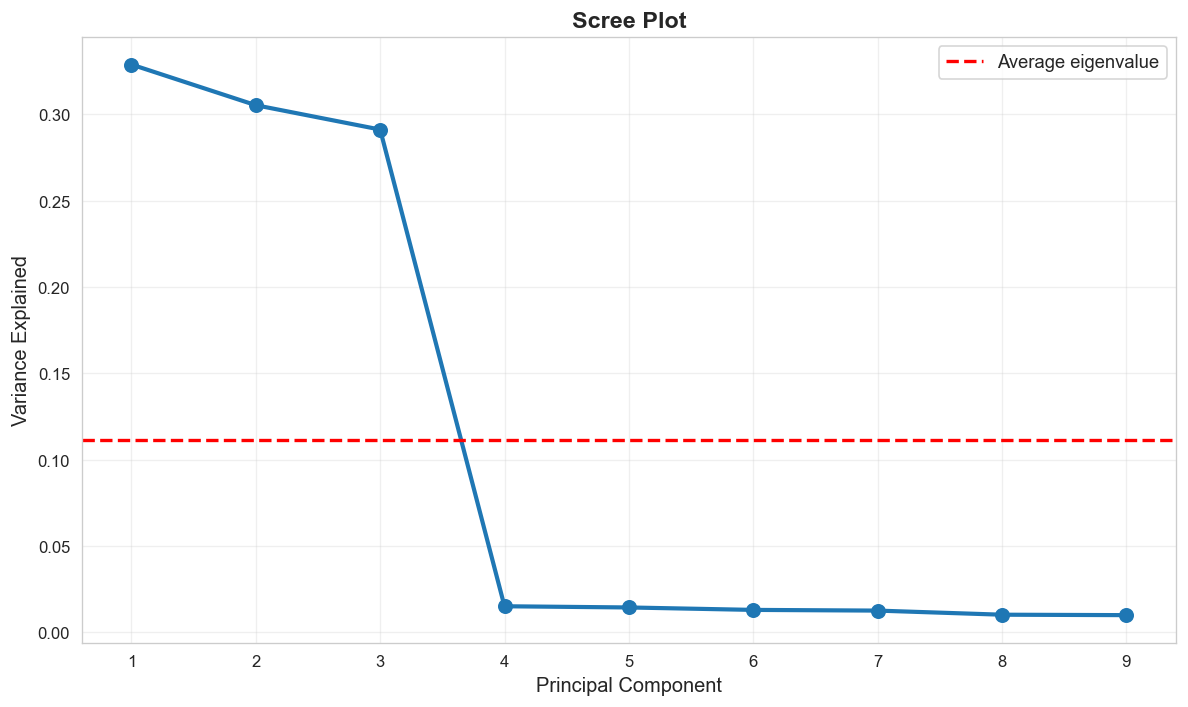

Saved: 01_scree_plot.png


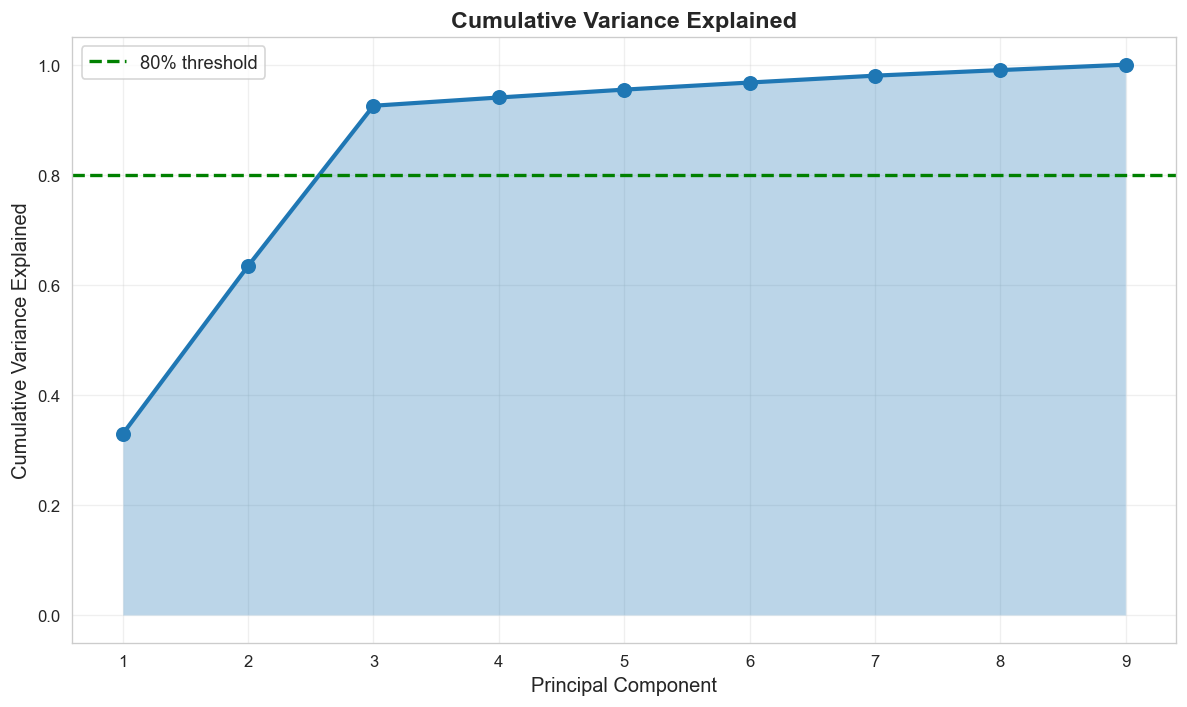

Saved: 02_cumulative_variance.png


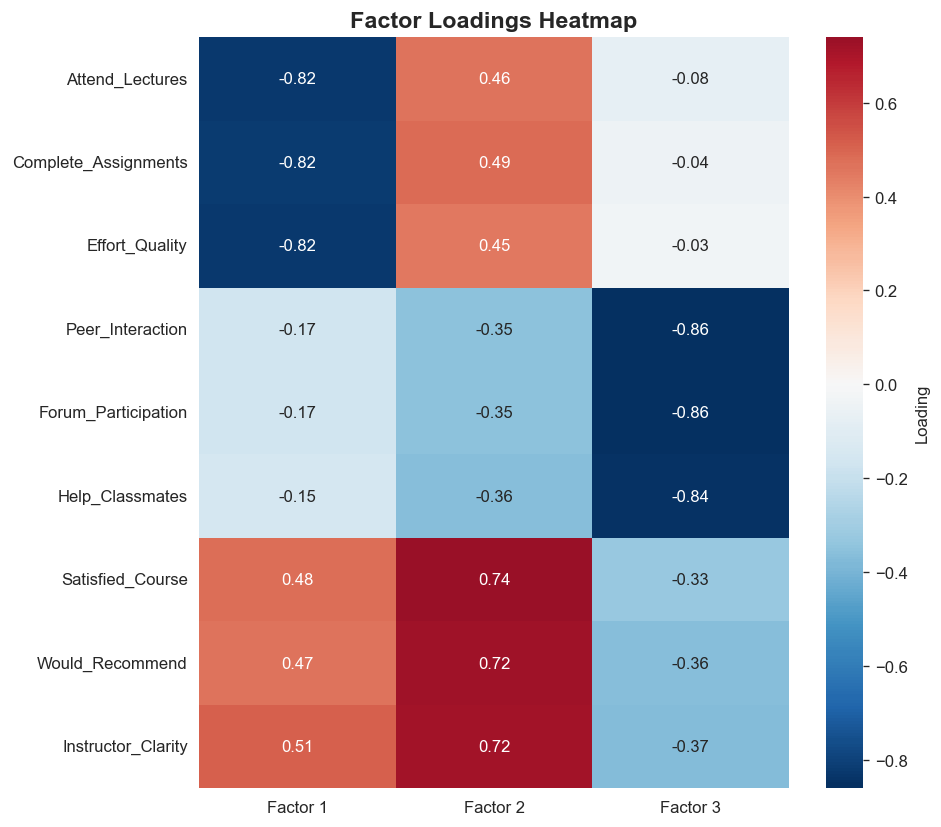

Saved: 03_loadings_heatmap.png

Saved survey data


In [7]:
## 5. Visualizations

os.makedirs('figures', exist_ok=True)

# 1. Scree Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(variance_explained) + 1), variance_explained, 'o-', linewidth=2.5, markersize=8)
ax.axhline(y=1/len(variables), color='red', linestyle='--', linewidth=2, label='Average eigenvalue')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Variance Explained', fontsize=12)
ax.set_title('Scree Plot', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/01_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 01_scree_plot.png')

# 2. Cumulative variance explained
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', linewidth=2.5, markersize=8)
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
ax.fill_between(range(1, len(cumulative_variance) + 1), cumulative_variance, alpha=0.3)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Cumulative Variance Explained', fontsize=12)
ax.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/02_cumulative_variance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 02_cumulative_variance.png')

# 3. Heatmap of loadings
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Loading'})
ax.set_title('Factor Loadings Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_loadings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 03_loadings_heatmap.png')

df.to_csv('educational_survey_data.csv', index=False)
print('\nSaved survey data')

In [8]:
## 6. PDF Handout Generation

from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = 'Ch20_FactorAnalysis_Handout.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=letter, rightMargin=0.75*inch, leftMargin=0.75*inch,
                        topMargin=0.75*inch, bottomMargin=0.75*inch)

styles = getSampleStyleSheet()
styleN = styles['Normal']
styleN.fontSize = 11
styleN.alignment = TA_JUSTIFY

story = []
story.append(Paragraph('<b>Chapter 20: Factor Analysis</b>', styles['Heading1']))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>1. Introduction</b>', styles['Heading2']))
intro = (
    'Exploratory Factor Analysis (EFA) identifies underlying latent constructs. '
    'Scree plots guide factor extraction; loadings indicate item-factor relationships.'
)
story.append(Paragraph(intro, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>2. Dataset</b>', styles['Heading2']))
dataset = f'{len(variables)} survey items from {n_respondents} respondents.'
story.append(Paragraph(dataset, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>3. Methods</b>', styles['Heading2']))
methods = (
    f'Principal Component Analysis performed; scree plot identified {n_factors} factors. '
    'Factor Analysis conducted with maximum likelihood estimation.'
)
story.append(Paragraph(methods, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>4. Results</b>', styles['Heading2']))
story.append(Spacer(1, 6))

try:
    if os.path.exists('figures/01_scree_plot.png'):
        story.append(Image('figures/01_scree_plot.png', width=480, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 1: Scree plot shows variance explained by each component.', styleN))
        story.append(Spacer(1, 12))
except: pass

try:
    if os.path.exists('figures/02_cumulative_variance.png'):
        story.append(Image('figures/02_cumulative_variance.png', width=480, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 2: Cumulative variance explained shows information retained.', styleN))
        story.append(Spacer(1, 12))
except: pass

story.append(PageBreak())
story.append(Paragraph('<b>5. Interpretation</b>', styles['Heading2']))
interp = (
    f'{n_factors} factors explain most variance. High loadings indicate strong item-factor associations. '
    'Factor interpretation comes from examining high-loading items.'
)
story.append(Paragraph(interp, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph(f'Generated on: {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', styleN))

try:
    doc.build(story)
    print(f'Saved PDF: {pdf_path}')
except Exception as e:
    print(f'PDF generation failed: {e}')

Saved PDF: Ch20_FactorAnalysis_Handout.pdf
